## **1. Environment Setup and Data Loading**
Detecting hardware, setting paths, and loading the test dataset using the saved metadata.

### **1.1: Imports, relative paths, and hardware detection.**

In [1]:
import os
import pickle
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Set up dynamic relative paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATASET_PATH = os.path.join(BASE_DIR, "Dataset")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
MODELS_DIR = os.path.join(BASE_DIR, "models")

# Hardware Detection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Evaluation Environment Initialized on {device}.")

Evaluation Environment Initialized on cuda.


### **1.2: Data restoration**

In [2]:
# Load dataset metadata saved during preprocessing
info_path = os.path.join(RESULTS_DIR, 'dataset_info.pkl')
with open(info_path, 'rb') as f:
    dataset_info = pickle.load(f)

BATCH_SIZE = dataset_info['batch_size'] 
INPUT_SIZE = dataset_info['input_size']

print(f"Loaded config - Input Size: {INPUT_SIZE}x{INPUT_SIZE}, Batch Size: {BATCH_SIZE}.")

# Test transformation pipeline (Strictly evaluation transforms, no data augmentation)
test_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Reconstruct the dataset class strictly for testing
class DeepfakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_to_label = {'fake': 0, 'real': 1}
        
        for class_name, label in self.class_to_label.items():
            class_path = os.path.join(root_dir, class_name)
            if os.path.exists(class_path):
                for img_file in os.listdir(class_path):
                    if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.images.append(os.path.join(class_path, img_file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            return self.__getitem__((idx + 1) % len(self.images))
            
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Initialize strictly the Test Dataset and DataLoader
test_dataset = DeepfakeDataset(os.path.join(DATASET_PATH, 'test'), transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Test Data Loading Complete. Total test batches: {len(test_loader)}.")

Loaded config - Input Size: 224x224, Batch Size: 64.
Test Data Loading Complete. Total test batches: 171.


## **2. Model Restoration**
Loading the standalone TorchScript model directly into memory.

In [3]:
# Path to the standalone model
model_path = os.path.join(MODELS_DIR, 'custom_cnn_standalone.pt')

# Load the model and map it directly to the active device
model = torch.jit.load(model_path, map_location=device)

# Ensure the model is in evaluation mode (disables dropout/batchnorm updates)
model.eval()

print("Standalone TorchScript Model loaded successfully and ready for evaluation.")

Standalone TorchScript Model loaded successfully and ready for evaluation.


## **3. Evaluation Engine**
Running the unseen test set through the model to collect predictions, probabilities, and ground truth labels.

### **3.1: Define the `evaluate_model` function.**

In [4]:
# Function to evaluate the model and collect metrics
def evaluate_model(model, test_loader, device):
    # BCEWithLogitsLoss for binary classification
    criterion = torch.nn.BCEWithLogitsLoss()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    # Disable gradient tracking for memory efficiency and speed
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            # Apply sigmoid to get probabilities between 0 and 1
            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).float()
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            # Store values on CPU for scikit-learn compatibility later
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    test_loss = running_loss / len(test_loader)
    test_acc = 100. * correct / total
    
    return test_loss, test_acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("Evaluation Engine Initialized.")

Evaluation Engine Initialized.


### **3.2: Execute the evaluation and store the raw arrays.**

In [6]:
print("Starting Evaluation on Test Set...")

# Execute the evaluation function
test_loss, test_acc, y_true, y_pred, y_probs = evaluate_model(model, test_loader, device)

print(f"Evaluation Complete.")
print(f"Overall Test Loss: {test_loss:.4f}")
print(f"Overall Test Accuracy: {test_acc:.2f}%")

Starting Evaluation on Test Set...
Evaluation Complete.
Overall Test Loss: 0.1734
Overall Test Accuracy: 92.82%


## **4. Metrics and Visual Analysis**
Generating classification reports and visualizing the model's performance.

### **4.1: Classfication Report (`Precision`, `Recall`, `F1`)**

In [7]:
# Generate detailed metrics for both Fake and Real classes
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

Classification Report:
              precision    recall  f1-score   support

        Fake       0.93      0.93      0.93      5492
        Real       0.93      0.93      0.93      5413

    accuracy                           0.93     10905
   macro avg       0.93      0.93      0.93     10905
weighted avg       0.93      0.93      0.93     10905



### **4.2: Confusion Matrix**

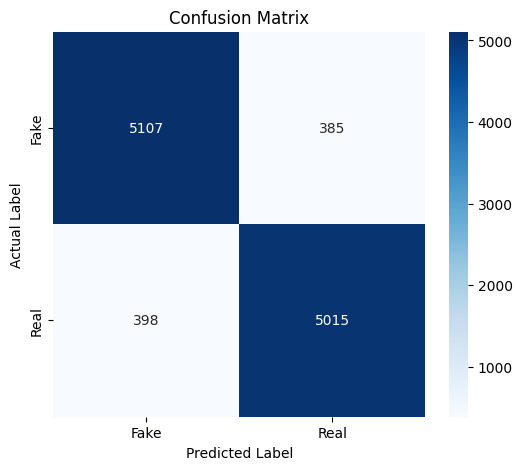

In [10]:
# Visualize true positives, false positives, true negatives, and false negatives
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### **4.3: ROC Curve and AUC**

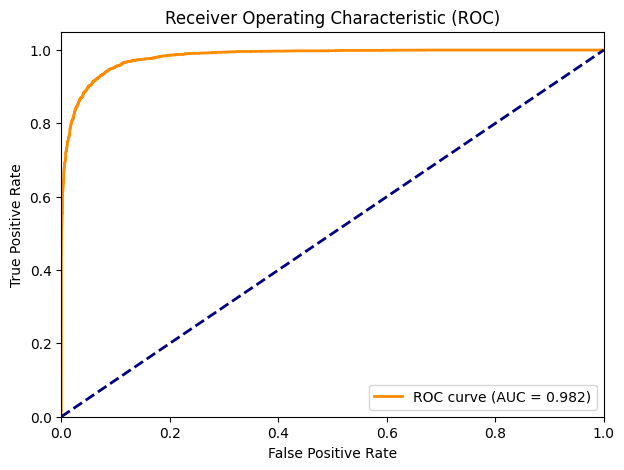

In [9]:
# Calculate False Positive Rate and True Positive Rate to plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()